In [11]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

In [12]:
## Read table
fname = 'vetting-v01'
fpath = f'mnt/tess/labels/{fname}.csv'

second_f=True
get_rid_of_n=True

# At the very end, remove every label that does not start with 'p', 'e' or 'j'?
remove_non_p_e_j = True

if second_f:
    fname_extra_objects = 'vetting-new-events-withfilenames'
    fpath_extra_objects=f'mnt/tess/labels/{fname_extra_objects}.csv'



# Read CSVs and set 'Astro ID' as index
all_table = pd.read_csv(fpath, index_col='Astro ID', low_memory=False)
print('Original table shape:', all_table.shape)

if second_f:
    long_per_table = pd.read_csv(fpath_extra_objects, index_col='Astro ID', low_memory=False)
    print('Long period table shape:', long_per_table.shape)

    all_table_2=pd.concat([all_table, long_per_table], ignore_index=False)

    all_table=all_table_2
    print('Table shape after adding events from the second spreadsheet:', all_table.shape)

Original table shape: (9344, 32)
Long period table shape: (1647, 59)
Table shape after adding events from the second spreadsheet: (10991, 60)


In [13]:
orig_table=all_table.copy()

In [14]:
#Print the unique values in orig_table['Final']

print("Unique values in 'Final' column before filtering:")
unique_values = orig_table['Final'].unique()
print(unique_values)

Unique values in 'Final' column before filtering:
['et' 'eb' 'pb' nan 'pt' 'pu' 'nu' 'eu' 'nb' 'nt' 'jj' 'ub' 'ets' 'eus'
 'pts' 'ebs' 'i' '#REF!' 'pus' 'IS' 'V' 'EB' 'O']


In [15]:
# # how many orig_table['Final'] are empty
# # Count the number of empty 'Final' entries

# empty_final_count = all_table['Final'].isna().sum()
# print(f"Number of empty 'Final' entries: {empty_final_count}")


In [16]:
# all_table.columns

In [17]:
## Rename or drop columns
# all_table.drop(columns=['Split'])
all_table = all_table.rename(columns={'filename': 'File',
                                      'Period': 'Per',
                                      'Duration': 'Dur',
                                      'Transit_Depth': 'Depth',
                                      'star_rad': 'SRad',
                                      'star_rad_est': 'SRadEst',
                                      'star_mass': 'SMass',})

In [18]:
## Make label columns
disps = ['e', 'p', 'n', 'b', 't', 'u', 'j']
users = ['mk', 'ch', 'et', 'md', 'as', 'dm', 'Tansu', 'Shishir']
for d in disps:
    all_table[f'disp_{d}'] = 0

# Set all TOIs commented with "CP", "PC", or "KP" with the label 'pu'
tois_planet_mask = (all_table['comment'].str.contains("(PC)", regex=False).astype(bool) | all_table['comment'].str.contains("(CP)", regex=False).astype((bool)) | all_table['comment'].str.contains("(KP)", regex=False).astype((bool)))

# # Print mismatches - not labelled planet by vetters, but is a TOI labelled KP, CP or PC (known planet, confirmed planet, planetary candidate)
print('Mismatches between TOI comment and vetting labels', all_table[tois_planet_mask][(all_table[tois_planet_mask]['Final'] != 'pt') & (~all_table[tois_planet_mask]['Final'].isna())]['TIC ID'])
print('Number of mismatches:', len(all_table[tois_planet_mask][(all_table[tois_planet_mask]['Final'] != 'pt') & (~all_table[tois_planet_mask]['Final'].isna())]))

# print('Mismatches between TOI comment and vetting labels',
#       all_table[tois_planet_mask][(~all_table[tois_planet_mask]['Final'].isin(['pt', 'pu'])) &
#                                     (~all_table[tois_planet_mask]['Final'].isna())]['TIC ID'])


all_table.loc[tois_planet_mask, 'Final'] = 'pu'
all_table.loc[tois_planet_mask, 'disp_p'] = 1  # Mark as 'p' for the purposes of vetting

if second_f:
    # Correct label 'EB' into 'eb', 'IS' into 'i' and V into 'jj'
    all_table.loc[all_table['Final'] == 'EB', 'Final'] = 'eb'
    all_table.loc[all_table['Final'] == 'IS', 'Final'] = 'i'
    all_table.loc[all_table['Final'] == 'V', 'Final'] = 'jj'

    # if label is O set as 'jj'
    all_table.loc[all_table['Final'] == 'O', 'Final'] = 'jj'

#Note: The new

## Set labels
def set_labels(row):
    a = ~row.isna()
    if row['Final'] == 'i':
        # skip objects labeled as "inside the star"
        row['Final'] = 'jj'  # 'i' should be treated as 'jj' in the final vetting
        row['disp_j'] = 1  # Mark as 'j' for the purposes of vetting
        return row
    if a['Final']:
        row[f'disp_{row["Final"][0]}'] = 1
        row[f'disp_{row["Final"][1]}'] = 1

    else:
        for user in users:
            if a[user] and row[user]:
                row[f'disp_{row[user][0]}'] += 1
                row[f'disp_{row[user][1]}'] += 1

    if row['Final']=='#REF!':
        # Handle the case of '#REF!' in Final column
        # Make it empty
        row['Final'] = np.nan


    if isinstance(row['Final'], str) and len(row['Final']) > 2:
        row['Final'] = row['Final'][:2]  # truncate to first two characters for consistency in case the label had 3 letters etc

    return row

all_table = all_table.apply(set_labels, axis=1)

Mismatches between TOI comment and vetting labels Astro ID
966       300217120
1260     1551168743
1261     1551168745
1270     1716106614
1447      391925531
            ...    
10504     341405597
10526     220524097
10535     382521776
10646     257467784
10764     230013442
Name: TIC ID, Length: 125, dtype: int64
Number of mismatches: 125


In [19]:
## Add more B, J, N labels from Astronet-triage into training set to J class

junk_examples_preprocessed=True

if not junk_examples_preprocessed:

    print('Initial table shape:', all_table.shape)
    print('---- Adding more B, J, N labels from Astronet triage ----')


    fpath_triage = 'mnt/tess/astronet/tces-v14-all.csv'
    # fpath_triage = 'mnt/tess/astronet/tces-v14-all.csv'

    table_triage = pd.read_csv(fpath_triage, header=0, low_memory=False).set_index('Astro ID')

    # Adding junk examples taking junk (J), contact binaries (B) and not sure (N) from astronet triage dataset
    junk_df = table_triage[(table_triage['Final'] == 'J') & (table_triage['File'].str.contains('mk_'))]

    print('Junk examples:', junk_df.shape)

    # Add more B examples
    b_df = table_triage[(table_triage['Final'] == 'B') & (table_triage['File'].str.contains('mk_'))]
    print('B examples:', b_df.shape)
    # Add more N examples
    n_df = table_triage[(table_triage['Final'] == 'N') & (table_triage['File'].str.contains('mk_'))]
    print('N examples:', n_df.shape)


    print('Total junk examples added (B,N treated as junk):', junk_df.shape[0] + b_df.shape[0] + n_df.shape[0])

    more_bjn_labels = pd.concat([junk_df, b_df, n_df], ignore_index=False)
    more_bjn_labels['disp_e'] = 0
    more_bjn_labels['disp_p'] = 0
    more_bjn_labels['disp_n'] = 0
    more_bjn_labels['disp_b'] = 0
    more_bjn_labels['disp_t'] = 0
    more_bjn_labels['disp_u'] = 0
    more_bjn_labels['disp_j'] = 1

    more_bjn_labels['Final'] = 'jj'

    new_columns = all_table.keys().intersection(more_bjn_labels.keys()) # Get only overlapping columns from all_table and more_bjn_labels: Index(['TIC ID', 'Final', 'Decision', 'mk', 'ch', 'et', 'md', 'as', 'dm', 'Split', 'RA', 'Dec', 'Tmag', 'Epoc', 'Per', 'Dur', 'Depth', 'SRad', 'SMass', 'SRadEst', 'File', 'disp_e', 'disp_p', 'disp_n', 'disp_b', 'disp_t', 'disp_u', 'disp_j'])

    all_table = pd.concat([all_table[new_columns], more_bjn_labels[new_columns]]) # Add 1000 Bs, 1000 Js, and 500 Ns into J class of all_table

    print('Final table shape after adding B, J, N labels from Astronet triage:', all_table.shape)

if junk_examples_preprocessed:
    print('Initial table shape:', all_table.shape)
    print('---- Adding more B, J, N labels from Astronet triage ----')


    fpath_junk='mnt/tess/labels/junk_data_2025dataset.csv'

    table_triage_junk = pd.read_csv(fpath_junk, header=0, low_memory=False).set_index('Astro ID')

    print('Junk triage table shape:', table_triage_junk.shape)

    more_bjn_labels = table_triage_junk
    more_bjn_labels['disp_e'] = 0
    more_bjn_labels['disp_p'] = 0
    more_bjn_labels['disp_n'] = 0
    more_bjn_labels['disp_b'] = 0
    more_bjn_labels['disp_t'] = 0
    more_bjn_labels['disp_u'] = 0
    more_bjn_labels['disp_j'] = 1

    more_bjn_labels['Final'] = 'jj'
    #Add to more_bjn_labels['Astro ID'] a value equal to max(all_table.index.max())
    max_id = all_table.index.max()
    more_bjn_labels.index = more_bjn_labels.index + max_id + 1

    new_columns = all_table.keys().intersection(more_bjn_labels.keys())

    all_table = pd.concat([all_table[new_columns], more_bjn_labels[new_columns]])

    print('Final table shape after adding B, J, N labels from Astronet triage:', all_table.shape)


Initial table shape: (10991, 69)
---- Adding more B, J, N labels from Astronet triage ----
Junk triage table shape: (6007, 32)
Final table shape after adding B, J, N labels from Astronet triage: (16998, 27)


In [20]:
print(f'Total entries: {len(all_table)}')

## And skip bad rows that have NaN in File', 'Per', 'Dur', 'Depth', or 'Tmag'
print("Skipping these TICs:", all_table[all_table[['File', 'Per', 'Dur', 'Depth', 'Tmag']].isna().any(axis=1)]['TIC ID'])
all_table = all_table[~all_table[['File', 'Per', 'Dur', 'Depth', 'Tmag']].isna().any(axis=1)]
print(f'Total after removing rows with missing File, Per, Dur, Depth, or Tmag: {len(all_table)}')


Total entries: 16998
Skipping these TICs: Astro ID
966       300217120
1260     1551168743
1261     1551168745
1270     1716106614
1447      391925531
            ...    
10698     272125414
10787     422912527
10791      83181153
10875     137685450
10982      44161614
Name: TIC ID, Length: 154, dtype: int64
Total after removing rows with missing File, Per, Dur, Depth, or Tmag: 16844


In [21]:
def assign_final_labels(data):
    # Create a copy to avoid modifying the original
    df = data.copy()

    # Get rows without a Final label
    mask_missing_final = df['Final'].isna()
    rows_to_update = df[mask_missing_final].index

    # Define the column groupings
    first_letter_cols = ['disp_e', 'disp_j', 'disp_n', 'disp_p']
    second_letter_cols = ['disp_t', 'disp_b', 'disp_u']

    all_disp_cols = first_letter_cols + second_letter_cols

    # Identify rows with no votes at all
    zero_votes_mask = (df[all_disp_cols].fillna(0).sum(axis=1) == 0) & mask_missing_final
    zero_votes_rows = df[zero_votes_mask].index

    # Only update rows with at least one vote
    rows_to_update = list(set(rows_to_update) - set(zero_votes_rows))

    print(f"Found {len(zero_votes_rows)} rows with no Final label AND no votes - these will be discarded")
    print(f"Assigning 'Final' labels to {len(rows_to_update)} rows that have votes...")

    for idx in rows_to_update:
        # For first letter: Get votes for e, j, n, p
        first_letter_votes = {col[-1]: df.loc[idx, col] for col in first_letter_cols}
        max_first_vote = max(first_letter_votes.values())

        # Check if there's a tie or no votes for first letter
        max_vote_disps = [d for d, count in first_letter_votes.items() if count == max_first_vote]
        if len(max_vote_disps) > 1:
            first_letter = 'p'  # Default to 'p' in case of tie
        else:
            first_letter = max_vote_disps[0]

        # For second letter: Get votes for t, b, u
        second_letter_votes = {col[-1]: df.loc[idx, col] for col in second_letter_cols}
        max_second_vote = max(second_letter_votes.values())

        # Check if there's a tie or no votes for second letter
        max_vote_second_letters = [l for l, count in second_letter_votes.items() if count == max_second_vote]
        if len(max_vote_second_letters) > 1 or max_second_vote == 0:
            second_letter = 'u'  # Default to 'u' in case of tie
        else:
            second_letter = max_vote_second_letters[0]

        # Assign the final label
        df.loc[idx, 'Final'] = first_letter + second_letter

    print(f"Finished assigning 'Final' labels.")

    # Show statistics of new Final values
    if len(rows_to_update) > 0:
        new_finals = df.loc[rows_to_update, 'Final'].value_counts()
        print("\nDistribution of newly assigned 'Final' values:")
        for label, count in new_finals.items():
            print(f"{label}: {count} ({count/len(rows_to_update)*100:.1f}%)")

        print('The ties were resolved by defaulting to "p" for the first letter and "u" for the second letter when there were multiple maximum votes.')

    return df, zero_votes_rows

# Apply the function to assign final labels and get rows to discard
all_table_updated, rows_to_discard = assign_final_labels(all_table)

# Discard rows with no votes and no Final label
all_table_updated = all_table_updated.drop(rows_to_discard)
print(f"\nRemoved {len(rows_to_discard)} rows with no votes and no Final label")

# Check how many entries now have a Final value
print("\nAfter update:")
print(f"Total number of entries with a Final value: {all_table_updated['Final'].notna().sum()}")
print(f"Number of entries without a Final value: {all_table_updated['Final'].isna().sum()}")
print(f"Total number of entries remaining: {len(all_table_updated)}")

# Show the updated distribution of Final values
print("\nUpdated distribution of Final values:")
print(all_table_updated['Final'].value_counts())

all_table=all_table_updated.copy()

Found 1213 rows with no Final label AND no votes - these will be discarded
Assigning 'Final' labels to 80 rows that have votes...
Finished assigning 'Final' labels.

Distribution of newly assigned 'Final' values:
eb: 27 (33.8%)
et: 24 (30.0%)
pt: 13 (16.2%)
eu: 7 (8.8%)
pu: 4 (5.0%)
pb: 4 (5.0%)
nt: 1 (1.2%)
The ties were resolved by defaulting to "p" for the first letter and "u" for the second letter when there were multiple maximum votes.

Removed 1213 rows with no votes and no Final label

After update:
Total number of entries with a Final value: 15631
Number of entries without a Final value: 0
Total number of entries remaining: 15631

Updated distribution of Final values:
Final
jj    6258
pu    5723
eb    2134
et    1195
pt     139
pb      84
eu      67
nu      12
nt      10
nb       8
ub       1
Name: count, dtype: int64


In [22]:
#Optional: get rid of the n label and any other things that are not 'p', 'e', 'j' (if remove_non_p_e_j is True)

print('Table shape before optional removal of entries starting with "n":', all_table.shape)

if get_rid_of_n:
    #Check which entries have 'Final' that starts with 'n' and remove those entries from all_table
    print("Removing entries with 'Final' starting with 'n'...")
    n_mask = all_table['Final'].str.startswith('n', na=False)
    n_count = n_mask.sum()
    print(f"Number of entries to remove: {n_count}")
    all_table = all_table[~n_mask]
    # Check the final shape of the table
    print(f"Final table shape after removing 'n' entries: {all_table.shape}")
# Final check of the distribution of Final values
# print("\nFinal distribution of 'Final' values after optional removal of 'n':")
# print(all_table['Final'].value_counts())

if remove_non_p_e_j:
    # Remove entries that do not start with 'p', 'e', or 'j'
    print("Removing entries with 'Final' not starting with 'p', 'e', or 'j'...")
    valid_mask = all_table['Final'].str.match('^[pej]', na=False)
    valid_count = valid_mask.sum()
    print(f"Number of valid entries to keep: {valid_count}")

    all_table = all_table[valid_mask]

# Check the final shape of the table
print(f"Final table shape after optional removing of non-p/e/j entries: {all_table.shape}")

# Final check of the distribution of Final values
print("\nFinal distribution of 'Final' values after optional removal of non-p/e/j entries:")
print(all_table['Final'].value_counts())


Table shape before optional removal of entries starting with "n": (15631, 27)
Removing entries with 'Final' starting with 'n'...
Number of entries to remove: 30
Final table shape after removing 'n' entries: (15601, 27)
Removing entries with 'Final' not starting with 'p', 'e', or 'j'...
Number of valid entries to keep: 15600
Final table shape after optional removing of non-p/e/j entries: (15600, 27)

Final distribution of 'Final' values after optional removal of non-p/e/j entries:
Final
jj    6258
pu    5723
eb    2134
et    1195
pt     139
pb      84
eu      67
Name: count, dtype: int64


Correcting the cases that had more than 1/2 votes in the disp scores

In [23]:
#Ensure that all examples only have 2 votes (or 1 in the case of j) in the disp scores


# # Calculate the total votes for each row by summing the specified columns
total_votes = all_table[['disp_e', 'disp_p', 'disp_n', 'disp_b', 'disp_t', 'disp_u', 'disp_j']].sum(axis=1)
all_table['total_votes'] = total_votes

# Get the rows with 3 or more votes
filtered_df = all_table[all_table['total_votes'] >= 3].copy()

# Report the number of examples being corrected
initial_count = len(filtered_df)
print(f"Number of examples with several votes at the beginning and being corrected: {initial_count}")

# List of all disposition columns
disp_columns = ['disp_e', 'disp_p', 'disp_n', 'disp_b', 'disp_t', 'disp_u', 'disp_j']

# Set all disposition columns to 0 initially for the filtered rows
for col in disp_columns:
    filtered_df[col] = 0

# Extract first and second letters from 'Final' column and set corresponding dispositions
for idx, row in filtered_df.iterrows():
    final_label = row['Final']

    # Skip if Final is not a string or doesn't have at least 2 characters
    if not isinstance(final_label, str) or len(final_label) < 2:
        continue

    # Get first and second characters
    first_char = final_label[0]
    second_char = final_label[1]

    # Set disposition columns based on first character (planet type)
    if first_char == 'e':
        filtered_df.at[idx, 'disp_e'] = 1
    elif first_char == 'p':
        filtered_df.at[idx, 'disp_p'] = 1
    elif first_char == 'j':
        filtered_df.at[idx, 'disp_j'] = 1

    # Set disposition columns based on second character (system type)
    if second_char == 'b':
        filtered_df.at[idx, 'disp_b'] = 1
    elif second_char == 't':
        filtered_df.at[idx, 'disp_t'] = 1
    elif second_char == 'u':
        filtered_df.at[idx, 'disp_u'] = 1
    elif second_char == 'j':
        filtered_df.at[idx, 'disp_j'] = 1

# After correction, sum the values in the disposition columns
corrected_votes = filtered_df[disp_columns].sum(axis=1)

# Count how many examples have more than 2 votes after correction
more_than_two_votes_count = (corrected_votes > 2).sum()
print(f"Number of examples that have more than 2 votes after correction: {more_than_two_votes_count}")

# Count how many examples have the 'n' label (disp_n == 1) at the end
n_label_count = (filtered_df['disp_n'] == 1).sum()
print(f"Number of examples that have the 'n' label at the end: {n_label_count}")

# Replace these rows in the original dataframe with the corrected ones
all_table.loc[all_table['total_votes'] >= 3] = filtered_df


Number of examples with several votes at the beginning and being corrected: 79
Number of examples that have more than 2 votes after correction: 0
Number of examples that have the 'n' label at the end: 0


Remove examples that have a very small fits file

In [24]:
# Before shuffling, remove objects that will result in an empty fits file because they haven't been observed
# Load the list of TICs from /pdo/users/pablomner/small_files_tics.txt, and remove those TIC IDs from all_table
# 1. Load the list of TICs
small_files_tics_fpath = "/pdo/users/pablomer/small_files_tics.txt"
small_files_tics = np.loadtxt(small_files_tics_fpath, dtype=int)

# 2. Remove the TIC IDs from all_table
print(f"Before removing TICs from small_files_tics.txt: {all_table.shape}")
all_table = all_table[~all_table['TIC ID'].isin(small_files_tics)]
print(f"After removing TICs from small_files_tics.txt: {all_table.shape}")


Before removing TICs from small_files_tics.txt: (15600, 28)
After removing TICs from small_files_tics.txt: (15471, 28)


Label distribution etc

Vote count statistics across selected disposition categories (e, j, n, p):
count    15471.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0
Name: selected_total_votes, dtype: float64

Distribution of total votes per instance (for selected categories):
selected_total_votes
1    15471
Name: count, dtype: int64

Percentage of instances by vote count (for selected categories):
1 votes: 15471 instances (100.0%)


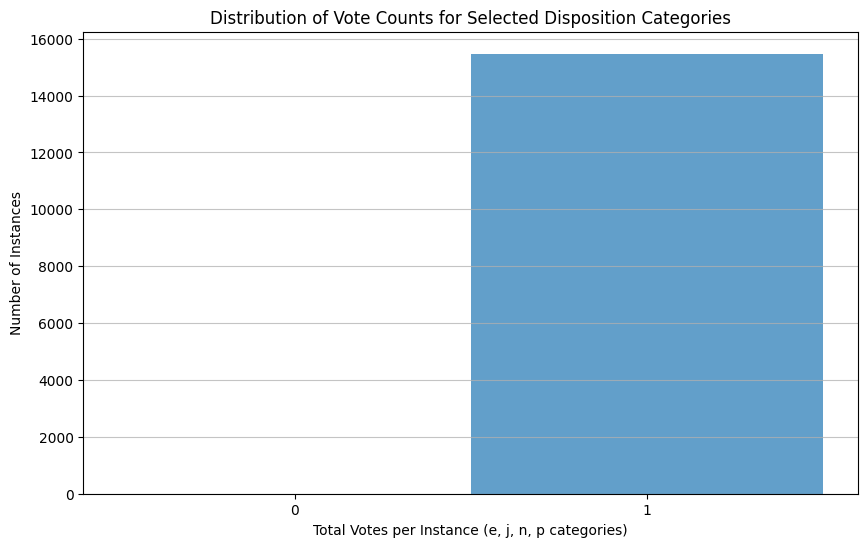

In [25]:
# Define the specific disposition columns to analyze
selected_disp_columns = ['disp_e', 'disp_j', 'disp_n', 'disp_p']

# Calculate total votes per row for just these categories
all_table['selected_total_votes'] = all_table[selected_disp_columns].sum(axis=1)

# Overall statistics
print("Vote count statistics across selected disposition categories (e, j, n, p):")
print(all_table['selected_total_votes'].describe())

# Distribution of vote counts
vote_distribution = all_table['selected_total_votes'].value_counts().sort_index()
print("\nDistribution of total votes per instance (for selected categories):")
print(vote_distribution)

# # Compare instances with and without Final values
# with_final = all_table[~all_table['Final'].isna()]
# without_final = all_table[all_table['Final'].isna()]

# print("\nVote count statistics for instances WITH a Final value:")
# print(with_final['selected_total_votes'].describe())

# print("\nVote count statistics for instances WITHOUT a Final value:")
# print(without_final['selected_total_votes'].describe())

# Optional: Calculate percentage of instances with each vote count
print("\nPercentage of instances by vote count (for selected categories):")
for votes, count in vote_distribution.items():
    pct = count / len(all_table) * 100
    print(f"{votes} votes: {count} instances ({pct:.1f}%)")

# Optional: Visualize with a histogram
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(all_table['selected_total_votes'],
         bins=range(0, max(all_table['selected_total_votes'])+2),
         align='left', alpha=0.7)
plt.xlabel('Total Votes per Instance (e, j, n, p categories)')
plt.ylabel('Number of Instances')
plt.title('Distribution of Vote Counts for Selected Disposition Categories')
plt.grid(axis='y', alpha=0.75)
plt.xticks(range(0, max(all_table['selected_total_votes'])+1))
plt.show()

In [26]:
# # Create a dataframe of all instances without votes
# no_votes_df = all_table[all_table['selected_total_votes'] == 0].copy()
# print(f"Number of instances without votes: {len(no_votes_df)}")

# # Check which ID column is available (trying common possibilities)
# potential_id_columns = ['TIC ID', 'AstroID', 'id', 'File']
# id_column = None

# for col in potential_id_columns:
#     if col in all_table.columns:
#         id_column = col
#         break

# if id_column is None:
#     print("Warning: Could not identify an ID column. Available columns are:")
#     print(all_table.columns)
#     # Use index as fallback
#     id_column = "index"
#     no_votes_df['index'] = no_votes_df.index

# print(f"Using '{id_column}' as identifier")

# # Check overlap with orig_table
# try:
#     if id_column == 'index':
#         orig_overlap_count = sum(idx in orig_table.index for idx in no_votes_df.index)
#     else:
#         orig_overlap_count = sum(id_val in set(orig_table[id_column]) for id_val in no_votes_df[id_column])

#     orig_percentage = (orig_overlap_count / len(no_votes_df)) * 100
#     print(f"\nInstances without votes in orig_table: {orig_overlap_count} ({orig_percentage:.1f}%)")
# except NameError:
#     print("Error: orig_table not defined")

# # Check overlap with long_per_table
# try:
#     if id_column == 'index':
#         long_overlap_count = sum(idx in long_per_table.index for idx in no_votes_df.index)
#     else:
#         long_overlap_count = sum(id_val in set(long_per_table[id_column]) for id_val in no_votes_df[id_column])

#     long_percentage = (long_overlap_count / len(no_votes_df)) * 100
#     long_table_percentage = (long_overlap_count / len(long_per_table)) * 100 if len(long_per_table) > 0 else 0
#     print(f"Instances without votes in long_per_table: {long_overlap_count} ({long_percentage:.1f}% of no-vote instances)")
#     print(f"This represents {long_table_percentage:.1f}% of all entries in long_per_table")
# except NameError:
#     print("Error: long_per_table not defined")

# # Check overlap with junk_df
# try:
#     if id_column == 'index':
#         junk_overlap_count = sum(idx in junk_df.index for idx in no_votes_df.index)
#     else:
#         junk_overlap_count = sum(id_val in set(junk_df[id_column]) for id_val in no_votes_df[id_column])

#     junk_percentage = (junk_overlap_count / len(no_votes_df)) * 100
#     junk_table_percentage = (junk_overlap_count / len(junk_df)) * 100 if len(junk_df) > 0 else 0
#     print(f"Instances without votes in junk_df: {junk_overlap_count} ({junk_percentage:.1f}% of no-vote instances)")
#     print(f"This represents {junk_table_percentage:.1f}% of all entries in junk_df")
# except NameError:
#     print("Error: junk_df not defined")

# # Display sample of instances without votes
# print("\nSample of instances without votes (first 10 rows):")
# display(no_votes_df.head(10))

# # Save the dataframe of instances without votes
# # Uncomment the following line to save to CSV
# # no_votes_df.to_csv('instances_without_votes.csv', index=False)

# print("\nThe dataframe of instances without votes is stored in 'no_votes_df'")

In [27]:
# # Plot label distribution

# from matplotlib import pyplot as plt
# labels = ['p', 'e', 'n', 'j']
# labels2 = ['t', 'b', 'u']

# counts = [sum(all_table['disp_{}'.format(l)] > 0) for l in labels]
# counts2 = [sum(all_table['disp_{}'.format(l)] > 0) for l in labels2]

# plt.figure()
# ax = plt.bar(labels, counts)
# for i in range(len(labels)):
#     b = ax[i]
#     height = b.get_height()
#     x, y = b.get_xy()
#     plt.annotate(
#         '{} - {:.0%}'.format(counts[i], counts[i] / sum(counts)),
#         (x + 0.25, y + height + 20))
# plt.tight_layout()

# # plt.figure()
# ax2 = plt.bar(labels2, counts2)
# for i in range(len(labels2)):
#     b = ax2[i]
#     height = b.get_height()
#     x, y = b.get_xy()
#     plt.annotate(
#         '{} - {:.0%}'.format(counts2[i], counts2[i] / sum(counts2)),
#         (x + 0.25, y + height + 20))
# plt.tight_layout()


/tmp/ipykernel_103653/681856952.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


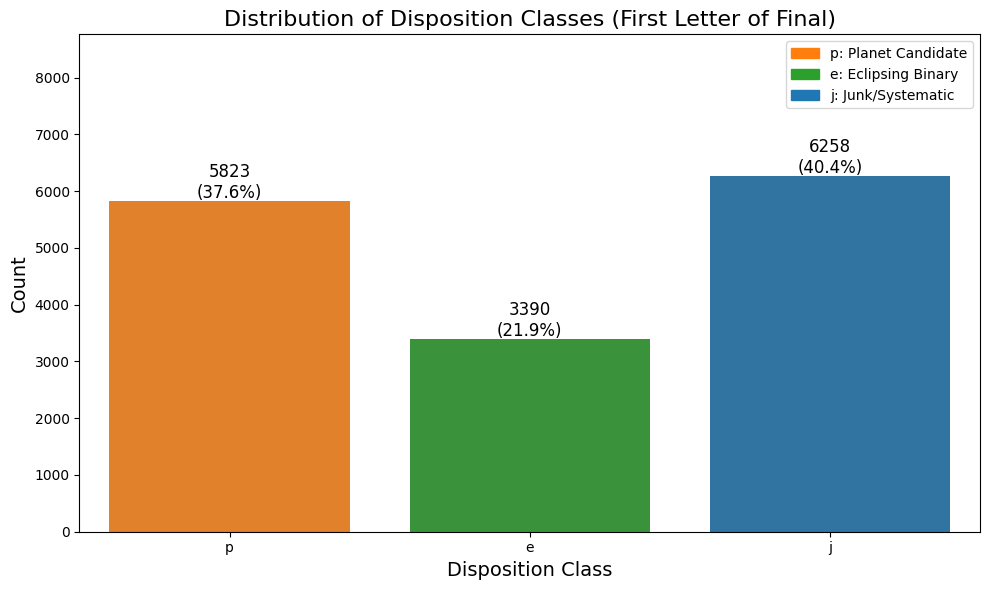

In [28]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

# Check if get_rid_of_n is defined, otherwise default to False
try:
    get_rid_of_n
except NameError:
    get_rid_of_n = False

# Extract the first letter of the Final column
all_table['first_letter'] = all_table['Final'].str[0]

# Define the class labels and their colors
labels = {
    'p': 'Planet Candidate',
    'e': 'Eclipsing Binary',
    'j': 'Junk/Systematic',
}

# Add 'n' if we're keeping it
if not get_rid_of_n:
    labels['n'] = 'Not Transit-Like'

# Define colors for each class
colors = {
    'p': '#ff7f0e',  # orange
    'e': '#2ca02c',  # green
    'j': '#1f77b4',  # blue
    'n': '#d62728'   # red
}

# Count the occurrences of each first letter (only for classes we're keeping)
first_letter_counts = all_table['first_letter'].value_counts().reindex(list(labels.keys()))

# Create a bar plot
plt.figure(figsize=(10, 6))
sns.barplot(
    x=first_letter_counts.index,
    y=first_letter_counts.values,
    palette=[colors[c] for c in first_letter_counts.index]
)

# Add labels and title
plt.title('Distribution of Disposition Classes (First Letter of Final)', fontsize=16)
plt.xlabel('Disposition Class', fontsize=14)
plt.ylabel('Count', fontsize=14)

# Add data labels on top of each bar
for i, count in enumerate(first_letter_counts):
    plt.text(i, count + (max(first_letter_counts) * 0.01),
             f'{count}\n({count/sum(first_letter_counts)*100:.1f}%)',
             ha='center', fontsize=12)

# Create legend handles
handles = [plt.Rectangle((0,0),1,1, color=colors[k]) for k in labels.keys()]
plt.legend(handles, [f"{k}: {v}" for k, v in labels.items()], loc='upper right')

plt.ylim(0, max(first_letter_counts) * 1.4)

plt.tight_layout()
plt.show()

Cross-validation split

In [29]:
import os
import pandas as pd
from sklearn.model_selection import StratifiedKFold

X=all_table.copy() # Use the final table with all the data

# Assume X is your full DataFrame containing both features and the 'Final' label column.
n_folds = 5
skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)

# Define file naming parameters
# fname = "your_fname"  # Update this with your identifier
NAME = "tois-triageJs-nocentroid-april2025"  # Update this with your identifier

# Save the complete dataset (optional)
all_csv_path = f"mnt/tess/astronet/tces-{fname}-{NAME}-all.csv"
if os.path.exists(all_csv_path):
    print("*****\nAlready saved TCE csv files. Overwriting the existing file.\n*****")
    X.to_csv(all_csv_path, index=False)
else:
    X.to_csv(all_csv_path, index=False)

# Perform stratified k-fold splitting and save each fold's train/validation splits
fold = 1

for train_idx, val_idx in skf.split(X, X['Final']):
    train_df = X.iloc[train_idx]
    val_df = X.iloc[val_idx]

    print(f"Fold {fold}: train size = {len(train_df)}, val size = {len(val_df)}")

    train_csv_path = f"mnt/tess/astronet/crossvalcsvs/tces-{fname}-{NAME}-train_fold{fold}.csv"
    val_csv_path = f"mnt/tess/astronet/crossvalcsvs/tces-{fname}-{NAME}-val_fold{fold}.csv"

    train_df.to_csv(train_csv_path, index=True)
    val_df.to_csv(val_csv_path, index=True)

    fold += 1


*****
Already saved TCE csv files. Overwriting the existing file.
*****
Fold 1: train size = 12376, val size = 3095
Fold 2: train size = 12377, val size = 3094
Fold 3: train size = 12377, val size = 3094
Fold 4: train size = 12377, val size = 3094
Fold 5: train size = 12377, val size = 3094


Train-val-test split

In [30]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split

# Use the final table with all the data
X = all_table.copy()

# Define file naming parameters
# fname = "your_fname"  # Uncomment and set as needed
NAME = "tois-triageJs-nocentroid-april2025"  # Update this with your identifier

# Save the complete dataset (optional)
all_csv_path = f"mnt/tess/astronet/tces-{fname}-{NAME}-all2.csv"
if os.path.exists(all_csv_path):
    print("*****\nAlready saved TCE csv files. Overwriting the existing file.\n*****")
X.to_csv(all_csv_path, index=True)

# Perform a single split into train, validation, and test sets.
# First, split off the test set (10% of the data)
t_train, t_test = train_test_split(
    X,
    test_size=0.1,
    random_state=42,
    stratify=X['Final']
)

# Next, split the remaining 90% into training and validation sets.
# Using test_size=1/9 results in ~10% validation overall.
t_train, t_val = train_test_split(
    t_train,
    test_size=1./9,
    random_state=42,
    stratify=t_train['Final']
)

# Print sizes and duplicate count
print(f'Split sizes. Train: {len(t_train)}; Valid: {len(t_val)}; Test: {len(t_test)}')
print(f'Duplicate TICs: {len(X.index.values) - len(set(X.index.values))}')
print('Splits')
print('  train:', len(t_train))
print('  val:', len(t_val))
print('  test:', len(t_test))

# Check that label arrays have at least one active label in each example.
label_cols = ['disp_e', 'disp_p', 'disp_n', 'disp_b', 'disp_t', 'disp_u', 'disp_j']
assert not any((t_train[label_cols].sum(axis=1)) == 0)
assert not any((t_val[label_cols].sum(axis=1)) == 0)
assert not any((t_test[label_cols].sum(axis=1)) == 0)

# Save the splits to CSV files
t_train.to_csv(f"mnt/tess/astronet/tces-{fname}-{NAME}-train2.csv", index=True)
t_val.to_csv(f"mnt/tess/astronet/tces-{fname}-{NAME}-val2.csv", index=True)
t_test.to_csv(f"mnt/tess/astronet/tces-{fname}-{NAME}-test2.csv", index=True)


Split sizes. Train: 12376; Valid: 1547; Test: 1548
Duplicate TICs: 0
Splits
  train: 12376
  val: 1547
  test: 1548


---
Extra: debugging why some have more than 2 votes

In [31]:
# # Calculate the total votes for each row by summing the specified columns
# total_votes = all_table[['disp_e', 'disp_p', 'disp_n', 'disp_b', 'disp_t', 'disp_u', 'disp_j']].sum(axis=1)

# total_votes_1stletter=all_table[['disp_e', 'disp_p', 'disp_n', 'disp_j']].sum(axis=1)
# total_votes_2ndletter=all_table[['disp_b', 'disp_t', 'disp_u']].sum(axis=1)
# total_votes_2ndletterplusj=all_table[['disp_b', 'disp_t', 'disp_u', 'disp_j']].sum(axis=1)

# # Option 1: Add the computed total_votes as a new column in the all_table DataFrame
# all_table['total_votes'] = total_votes

# # Option 2: Alternatively, create a new DataFrame containing the disposition columns and total_votes
# votes_df = all_table[['disp_e', 'disp_p', 'disp_n', 'disp_b', 'disp_t', 'disp_u', 'disp_j']].copy()
# votes_df['total_votes'] = total_votes
# votes_df['total_votes_1stletter'] = total_votes_1stletter
# votes_df['total_votes_2ndletter'] = total_votes_2ndletter
# votes_df['total_votes_2ndletterplusj'] = total_votes_2ndletterplusj

# # Print the first few rows to verify the new column has been added (choose one of the following)
# print("Updated all_table with total_votes column:")
# print(all_table.head())

# print("\nNew DataFrame with disposition columns and total_votes column:")
# print(votes_df.head())
